<center><H1 style = "color: green">GERMAN CREDIT RISK ANALYSIS</H1> </center>

***

## Contents

German Credit Dataset
1. Age (numeric)
2. Sex (text: male, female)
3. Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
4. Housing (text: own, rent, or free)
5. Saving accounts (text - little, moderate, quite rich, rich)
6. Checking account (numeric, in DM - Deutsch Mark)
7. Credit amount (numeric, in DM)
8. Duration (numeric, in month)
9. Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)


#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load 'german_credit_data.csv' and store it in a dataframe

In [2]:
df=pd.read_csv('german_credit_data.csv')

#### View top 5 rows

In [3]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


#### Do data analysis with the dataset ( shape of dataset,columns,null objects,unique elements)

#### Shape

In [4]:
df.shape

(1000, 11)

#### Columns

In [5]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

#### Number of null objects in each column

In [6]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

### Fill all null objects with 'Unknown'

In [7]:
df.fillna('Unknown', inplace=True)
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

#### Unique elements in each column

In [8]:
columns=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']
for i in columns:
    print(f'Unique values in {i}', df[i].unique())

Unique values in Age [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]
Unique values in Sex ['male' 'female']
Unique values in Job [2 1 3 0]
Unique values in Housing ['own' 'free' 'rent']
Unique values in Saving accounts ['Unknown' 'little' 'quite rich' 'rich' 'moderate']
Unique values in Checking account ['little' 'moderate' 'Unknown' 'rich']
Unique values in Credit amount [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315

##### Create a New column Id by replacing unnamed column

In [9]:
df=df.rename(columns={'Unnamed: 0':'Id'})

In [10]:
df.head()

,Id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,Unknown,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


#### Find the information of the dataset


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   1000 non-null   object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


#### Find basic statistical information about the dataset

In [12]:
df.describe()

,Id,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


#### Fetch the following groupby results

In [13]:
df.groupby(['Sex', 'Risk', 'Purpose']).size()

Sex     Risk  Purpose            
female  bad   business                 7
              car                     40
              domestic appliances      2
              education                9
              furniture/equipment     28
              radio/TV                19
              repairs                  2
              vacation/others          2
        good  business                12
              car                     54
              domestic appliances      4
              education               15
              furniture/equipment     46
              radio/TV                66
              repairs                  3
              vacation/others          1
male    bad   business                27
              car                     66
              domestic appliances      2
              education               14
              furniture/equipment     30
              radio/TV                43
              repairs                  6
              vacation/

In [14]:
df.groupby(['Purpose', 'Risk', 'Sex']).size()

Purpose              Risk  Sex   
business             bad   female      7
                           male       27
                     good  female     12
                           male       51
car                  bad   female     40
                           male       66
                     good  female     54
                           male      177
domestic appliances  bad   female      2
                           male        2
                     good  female      4
                           male        4
education            bad   female      9
                           male       14
                     good  female     15
                           male       21
furniture/equipment  bad   female     28
                           male       30
                     good  female     46
                           male       77
radio/TV             bad   female     19
                           male       43
                     good  female     66
                       

## <span style = "color: orange"> Data Visualization </span>

### Plot the graphs shown below

C:\Users\vinaya.k\AppData\Local\Temp\ipykernel_19936\850241952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette=['blue','orange'])


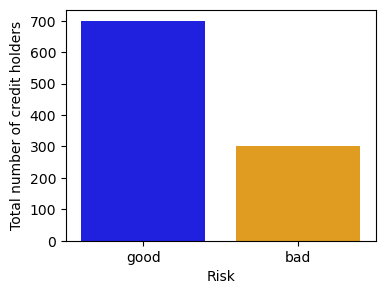

In [15]:
plt.figure(figsize=(4,3))
sns.countplot(x='Risk', data=df, palette=['blue','orange'])
plt.xlabel('Risk')
plt.ylabel('Total number of credit holders')
plt.show()

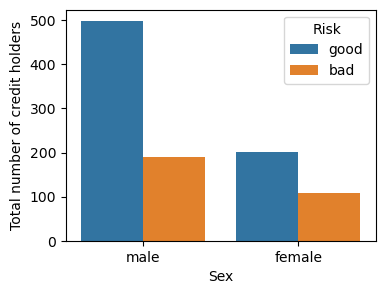

In [16]:
plt.figure(figsize=(4,3))
sns.countplot(x='Sex',data=df,hue='Risk')
plt.xlabel('Sex')
plt.ylabel('Total number of credit holders')
plt.show()

Text(0, 0.5 'Total number of credit holders')


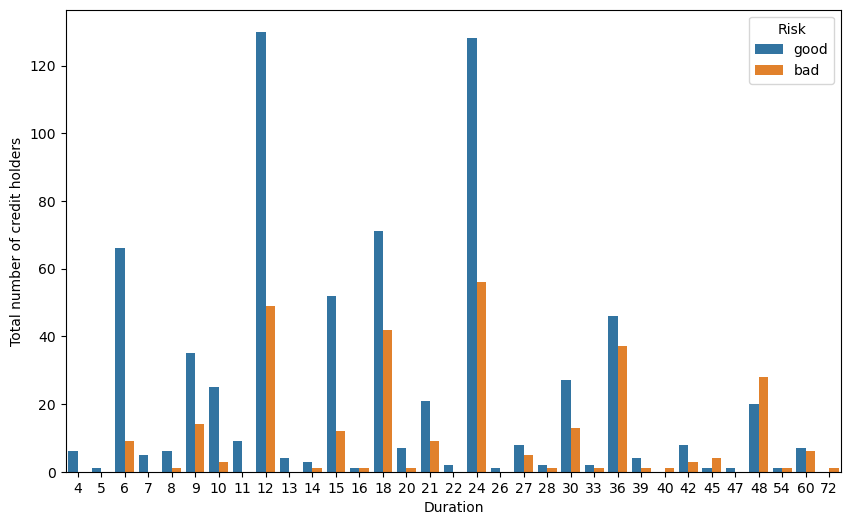

In [17]:
print("Text(0, 0.5 'Total number of credit holders')")
plt.figure(figsize=(10,6))
sns.countplot(x='Duration',data=df,hue='Risk')
plt.xlabel('Duration')
plt.ylabel('Total number of credit holders')
plt.show()

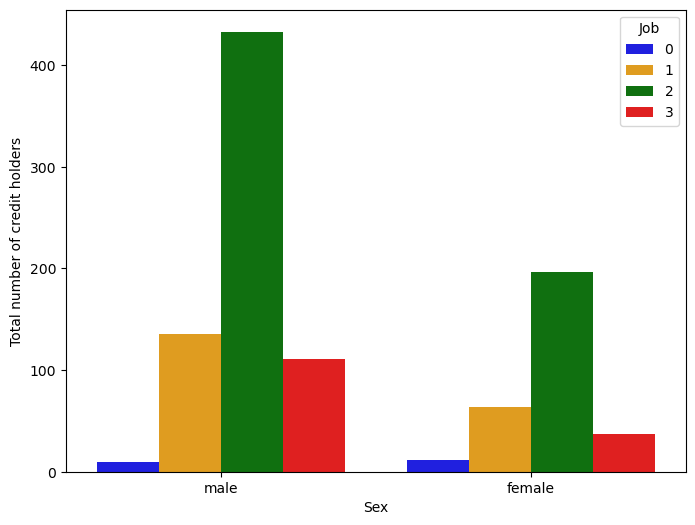

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(x='Sex',data=df,hue='Job',palette=['blue','orange','green','red'])
plt.xlabel('Sex')
plt.ylabel('Total number of credit holders')
plt.show()

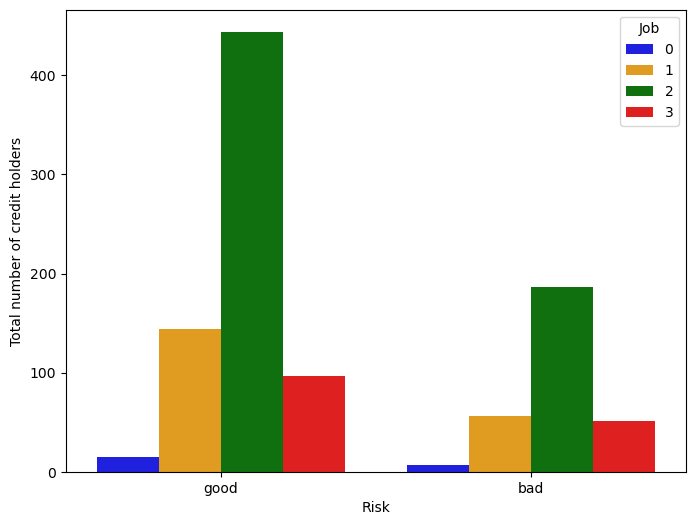

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(x='Risk',data=df,hue='Job',palette=['blue','orange','green','red'])
plt.xlabel('Risk')
plt.ylabel('Total number of credit holders')
plt.show()

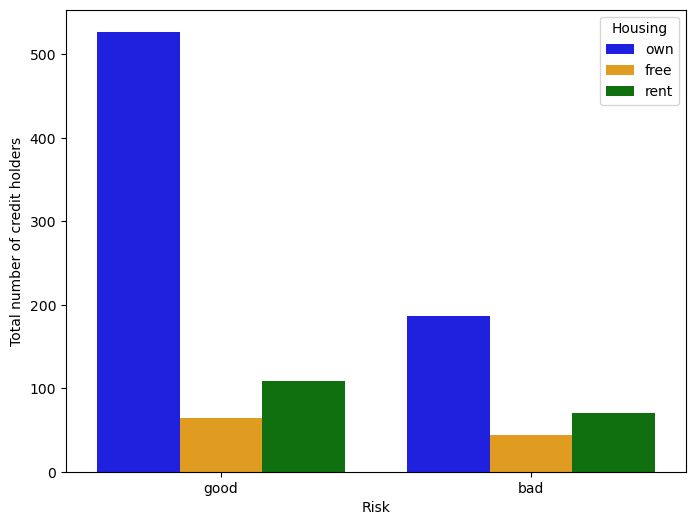

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(x='Risk',data=df,hue='Housing',palette=['blue','orange','green'])
plt.xlabel('Risk')
plt.ylabel('Total number of credit holders')
plt.show()

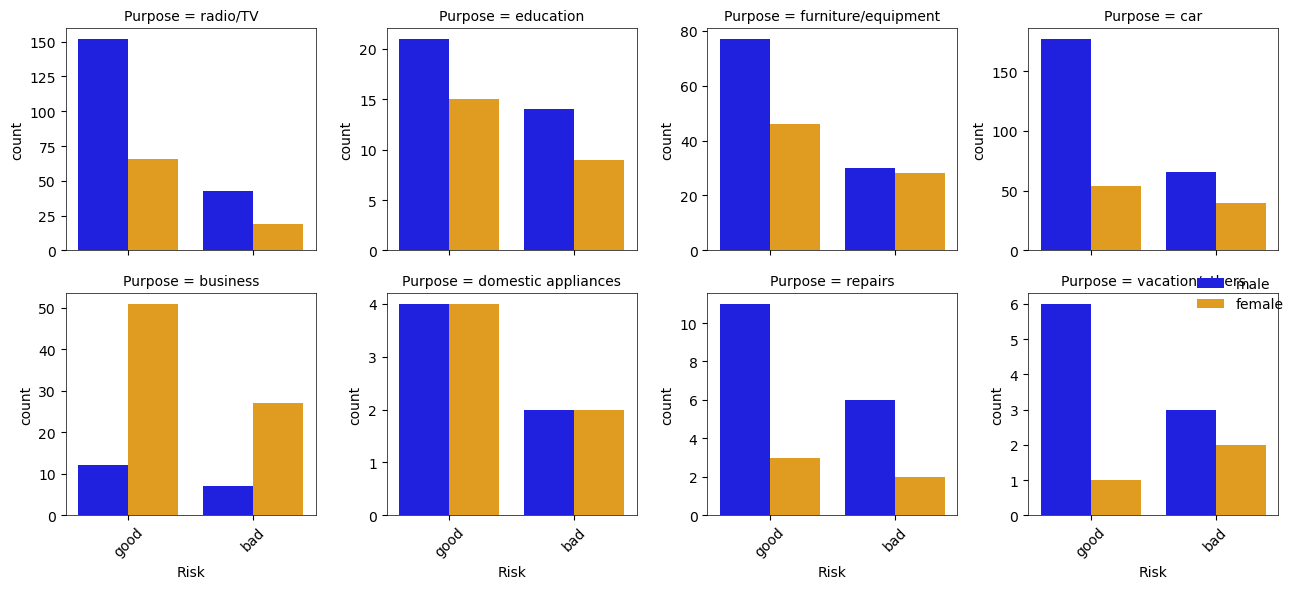

In [21]:
g =sns.FacetGrid(df,col='Purpose', col_wrap=4, height=3, sharey=False)
g.map_dataframe(sns.countplot,x='Risk',hue='Sex',palette=['blue','orange']).add_legend()

for ax in g.axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_edgecolor('black')
    ax.tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

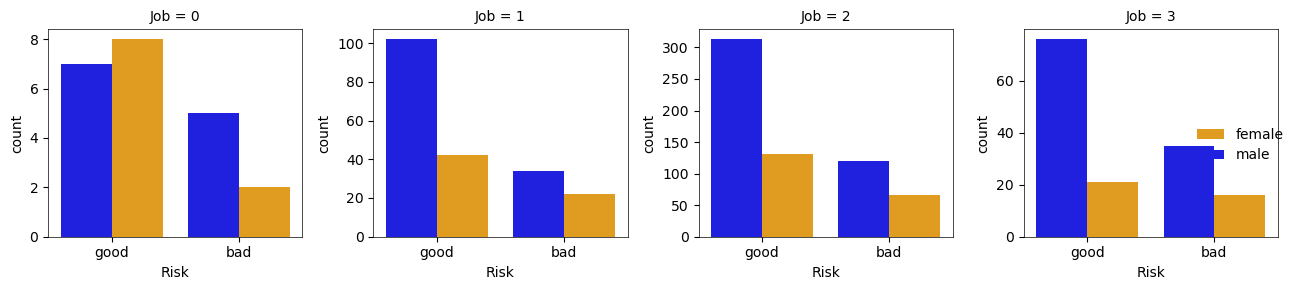

In [22]:
g =sns.FacetGrid(df,col='Job',col_wrap=4,height=3,sharey=False)
g.map_dataframe(sns.countplot,x='Risk',hue='Sex',palette=['blue','orange']).add_legend()

for ax in g.axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_edgecolor('black')
    ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

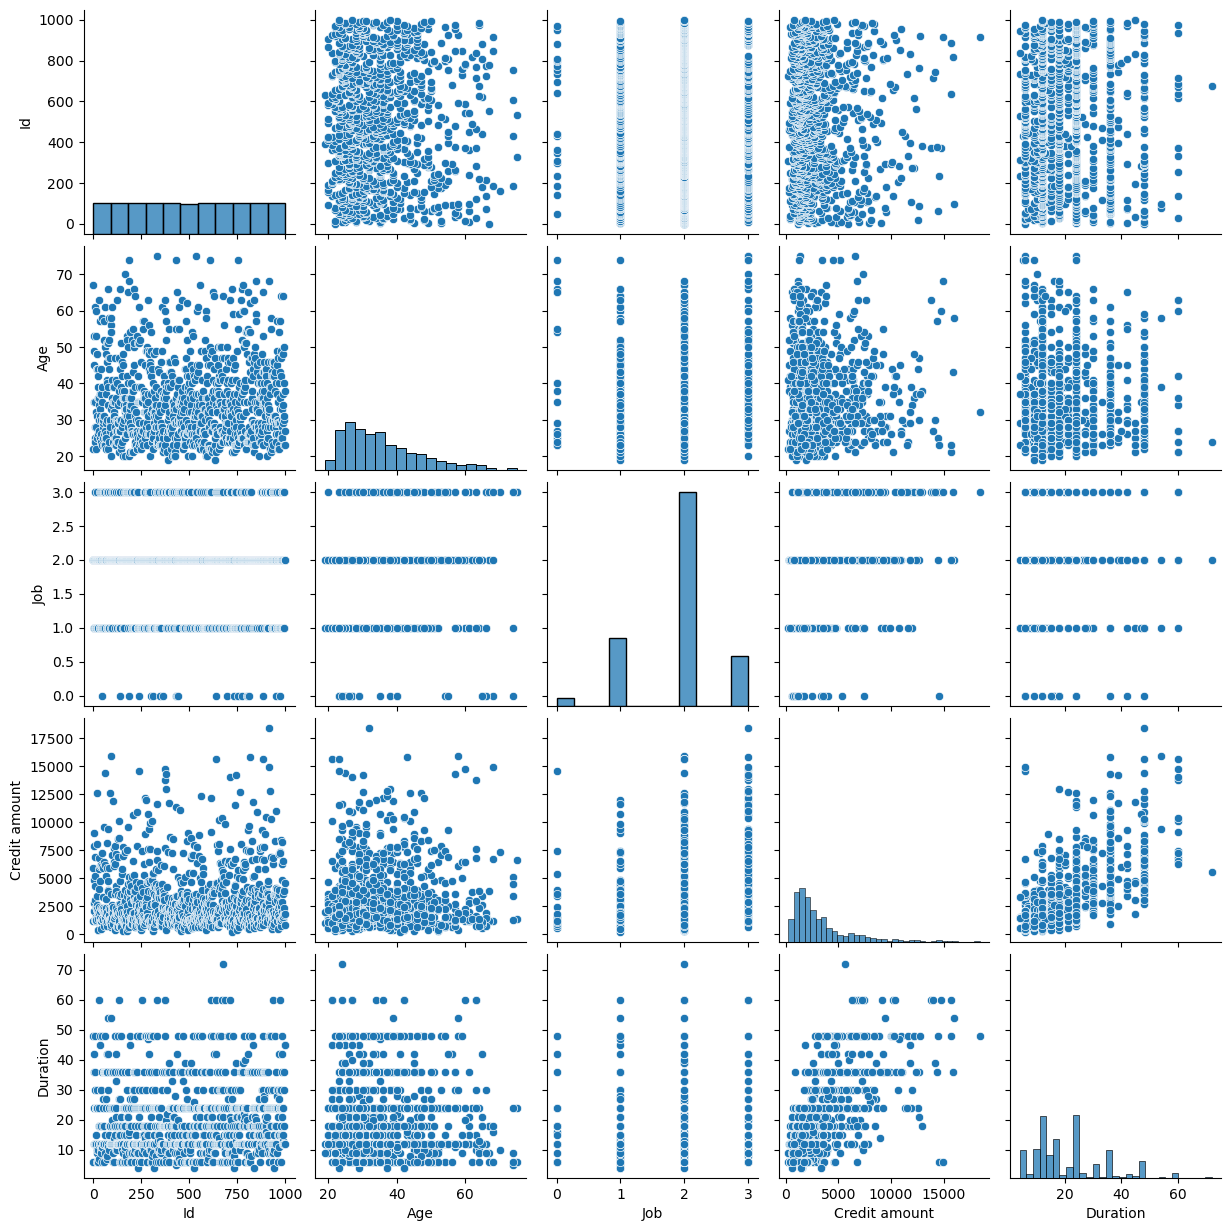

In [23]:
sns.pairplot(df)
plt.show()

C:\Users\vinaya.k\AppData\Local\Temp\ipykernel_19936\979451040.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk',data=df,palette=['blue','orange'])


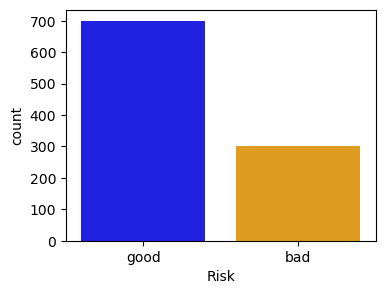

In [24]:
plt.figure(figsize=(4,3))
sns.countplot(x='Risk',data=df,palette=['blue','orange'])
plt.show()

# Preprocess the dataset:
**We have to convert all categorical values into numerical values.**

#### Convert purpose column using Dummy variables

In [25]:
dummies=pd.get_dummies(df['Purpose'])
df=pd.concat([df, dummies], axis=1)
df.head()

,Id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good,False,False,False,False,False,True,False,False
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,False,False,False,False,False,True,False,False
2,2,49,male,1,own,little,Unknown,2096,12,education,good,False,False,False,True,False,False,False,False
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,False,False,False,False,True,False,False,False
4,4,53,male,2,free,little,little,4870,24,car,bad,False,True,False,False,False,False,False,False


#### Use label encoding for rest of the categorical data

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()



In [27]:
categorical_columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Risk']
newdf=df.copy().drop(columns=['Id', 'Purpose'])
for i in categorical_columns:
    newdf[i]=le.fit_transform(newdf[i])

In [28]:
newdf.head(2)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
0,67,1,2,1,0,1,1169,6,1,False,False,False,False,False,True,False,False
1,22,0,2,1,1,2,5951,48,0,False,False,False,False,False,True,False,False


### Check the unique values in the new dataframe

In [29]:
for i in newdf.columns:
    print(f'Unique values in {i} are:', newdf[i].unique())

Unique values in Age are: [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]
Unique values in Sex are: [1 0]
Unique values in Job are: [2 1 3 0]
Unique values in Housing are: [1 0 2]
Unique values in Saving accounts are: [0 1 3 4 2]
Unique values in Checking account are: [1 2 0 3]
Unique values in Credit amount are: [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 1594

### Plot heatmap

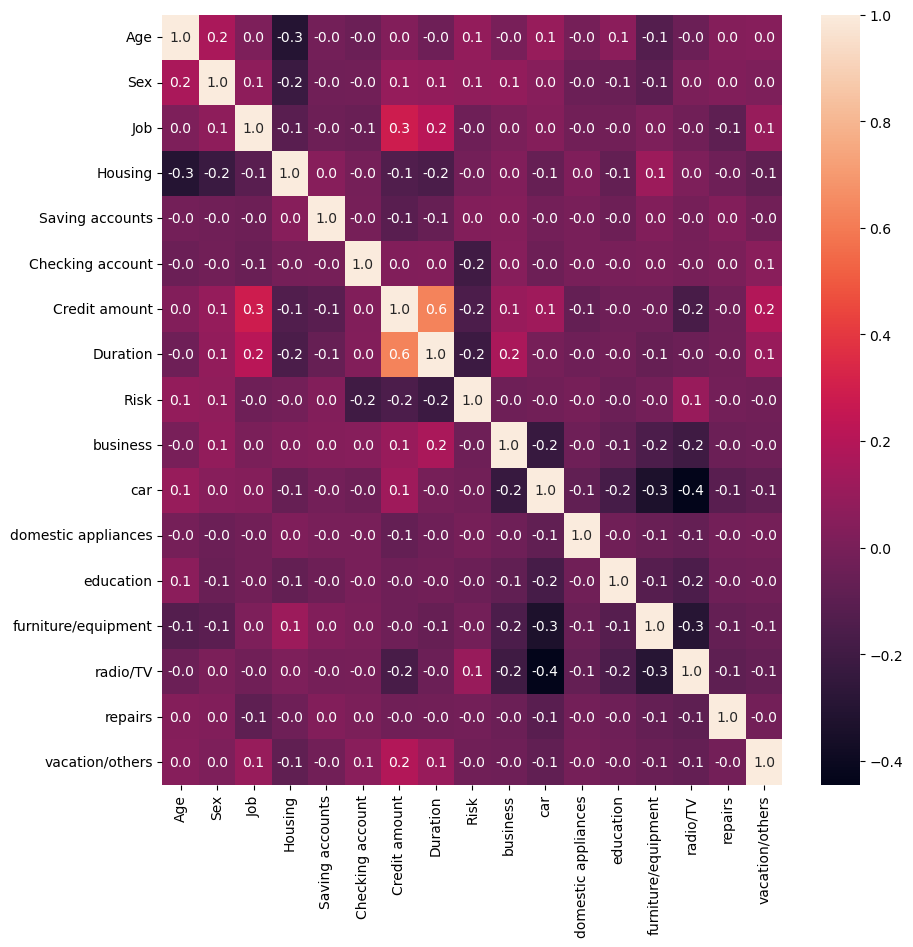

In [30]:
plt.figure(figsize=(10,10))
sns.heatmap(newdf.corr(numeric_only=True),annot=True,fmt='.1f')
plt.show()

## Select the Dependent(target) and Independent Variables:

In [31]:
X=newdf.drop(columns=['Risk'])
y=newdf['Risk']

# Standardize the data

In [32]:
from sklearn.preprocessing import StandardScaler


In [33]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X=pd.DataFrame(X_scaled,columns=X.columns)
X.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
0,2.766456,0.670280,0.146949,-0.133710,-1.231393,-0.001045,-0.745131,-1.236478,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
1,-1.191404,-1.491914,0.146949,-0.133710,-0.196609,1.044372,0.949817,2.248194,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
2,1.183312,0.670280,-1.383771,-0.133710,-0.196609,-1.046463,-0.416562,-0.738668,-0.327749,-0.712949,-0.110208,3.993639,-0.470108,-0.623610,-0.149983,-0.110208
3,0.831502,0.670280,0.146949,-2.016956,-0.196609,-0.001045,1.634247,1.750384,-0.327749,-0.712949,-0.110208,-0.250398,2.127172,-0.623610,-0.149983,-0.110208
4,1.535122,0.670280,0.146949,-2.016956,-0.196609,-0.001045,0.566664,0.256953,-0.327749,1.402626,-0.110208,-0.250398,-0.470108,-0.623610,-0.149983,-0.110208


# Split the data into training and testing set

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=100)

# Models:

## Random Forest Classifier.
** Let's choose the best estimator and parameters :GridSearchCV**

In [35]:
#let's check what params will be best suitable for random forest classification.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [36]:
param_grid={'max_depth':[0.5,1,5,10],'n_estimators':[16,32,50,100],'n_jobs':[1,2],'random_state':[1,10,20,42]}

In [37]:
gsv=GridSearchCV(RandomForestClassifier(),param_grid,scoring='accuracy')

In [38]:
gsv.fit(X_train,y_train)

C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
160 fits failed out of a total of 640.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _valid

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [0.5, 1, 5, 10],
                         'n_estimators': [16, 32, 50, 100], 'n_jobs': [1, 2],
                         'random_state': [1, 10, 20, 42]},
             scoring='accuracy')

In [39]:
print('Best estimator is:', gsv.best_estimator_)
print('Best parameters area:', gsv.best_params_)
print('Best score is:', gsv.best_score_)

Best estimator is: RandomForestClassifier(max_depth=10, n_jobs=1, random_state=10)
Best parameters area: {'max_depth': 10, 'n_estimators': 100, 'n_jobs': 1, 'random_state': 10}
Best score is: 0.7424999999999999


In [40]:
best_rf_model=gsv.best_estimator_
best_rf_model

RandomForestClassifier(max_depth=10, n_jobs=1, random_state=10)

### Check the accuracy score, Confusion metrics, Classification report and Cross val score

In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score

In [42]:
y_pred=best_rf_model.predict(X_test)
print('Accuracy score is:', accuracy_score(y_test,y_pred))
print('Confusion matrix:', confusion_matrix(y_test,y_pred))
print('Classification report:', classification_report(y_test,y_pred))
print('Cross validation score:', cross_val_score(best_rf_model,X, y,scoring='accuracy').mean())

Accuracy score is: 0.755
Confusion matrix: [[ 23  33]
 [ 16 128]]
Classification report:               precision    recall  f1-score   support

           0       0.59      0.41      0.48        56
           1       0.80      0.89      0.84       144

    accuracy                           0.76       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.74      0.76      0.74       200

Cross validation score: 0.748


#### Visualize the confusion matrix

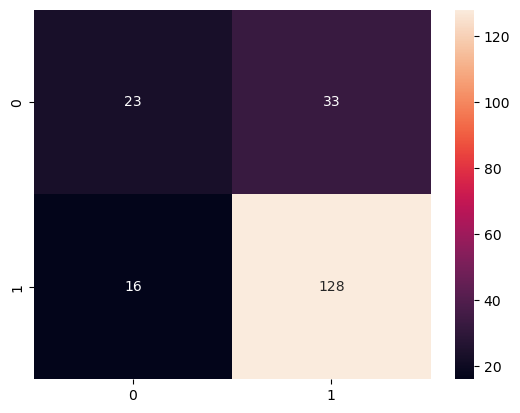

In [43]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

## SupportVectorClassifier:

In [44]:
from sklearn.svm import SVC

In [45]:
param_grid={'C': [0.75, 0.85, 0.95, 1], 'degree': [3,4,5], 'kernel':['linear', 'poly', 'rbf', 'sigmoid']}

In [46]:
gsv=GridSearchCV(SVC(),param_grid)

In [47]:
gsv.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.75, 0.85, 0.95, 1], 'degree': [3, 4, 5],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [48]:
print('Best estimator is:', gsv.best_estimator_)
print('Best parameters are:', gsv.best_params_)
print('Best score is:', gsv.best_score_)

Best estimator is: SVC(C=1, degree=4, kernel='poly')
Best parameters are: {'C': 1, 'degree': 4, 'kernel': 'poly'}
Best score is: 0.70375


In [49]:
best_svm=gsv.best_estimator_
best_svm

SVC(C=1, degree=4, kernel='poly')

In [50]:
y_pred=best_svm.predict(X_test)
print('Accuracy score is:', accuracy_score(y_test,y_pred))
print('Confusion metrics:', confusion_matrix(y_test,y_pred))
print('Classification report:', classification_report(y_test,y_pred))
print('Cross validation score:', cross_val_score(best_svm,X,y,scoring='accuracy').mean())

Accuracy score is: 0.675
Confusion metrics: [[  5  51]
 [ 14 130]]
Classification report:               precision    recall  f1-score   support

           0       0.26      0.09      0.13        56
           1       0.72      0.90      0.80       144

    accuracy                           0.68       200
   macro avg       0.49      0.50      0.47       200
weighted avg       0.59      0.68      0.61       200

Cross validation score: 0.708


## LogisticRegression

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
model=LogisticRegression()

In [53]:
model.fit(X_train,y_train)

LogisticRegression()

In [54]:
y_pred=model.predict(X_test)
print('Accuracy score:', accuracy_score(y_test,y_pred))
print('Confusion metrics:', confusion_matrix(y_test,y_pred))
print('Classification report:', classification_report(y_test,y_pred))
print('Cross val score:', cross_val_score(model,X,y,scoring='accuracy').mean())

Accuracy score: 0.7
Confusion metrics: [[  7  49]
 [ 11 133]]
Classification report:               precision    recall  f1-score   support

           0       0.39      0.12      0.19        56
           1       0.73      0.92      0.82       144

    accuracy                           0.70       200
   macro avg       0.56      0.52      0.50       200
weighted avg       0.64      0.70      0.64       200

Cross val score: 0.701


## AdaBoost: Classifier

In [55]:
from sklearn.ensemble import AdaBoostClassifier

In [56]:
model=AdaBoostClassifier(n_estimators=50,learning_rate=1,random_state=100)

In [57]:
model.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=1, random_state=100)

In [58]:
y_pred=model.predict(X_test)
print('Accuracy score is:', accuracy_score(y_test,y_pred))
print('Confusion metrics:', confusion_matrix(y_test,y_pred))
print('Classification report:', classification_report(y_test,y_pred))
print('Cross val score:', cross_val_score(model,X,y,scoring='accuracy').mean())

Accuracy score is: 0.75
Confusion metrics: [[ 19  37]
 [ 13 131]]
Classification report:               precision    recall  f1-score   support

           0       0.59      0.34      0.43        56
           1       0.78      0.91      0.84       144

    accuracy                           0.75       200
   macro avg       0.69      0.62      0.64       200
weighted avg       0.73      0.75      0.73       200

Cross val score: 0.717


#### View scores of the different models 

In [59]:
data={'Models':['Random Forest Classifier', 'Logistic Regression', 'Gradient Boost Classifier', 'Support Vector Classifier'],
      'Score':[ 0.755, 0.7, 0.75, 0.675]}
data1=pd.DataFrame(data,index=[0,1,2,3])
data1

,Models,Score
0,Random Forest Classifier,0.755
1,Logistic Regression,0.700
2,Gradient Boost Classifier,0.750
3,Support Vector Classifier,0.675


## ANALYZING THE RESULTS

**So now we have to decide which one is the best model, and we have two types of wrong values:**

* False Positive, means they won't pay the loan(Risk:Yes), but the model thinks they will.
* False Negative, means they will pay the loan(Risk:No), but the model said they won't.

**In my opinion:**

* Length of the dataset isn't enough, we need more data for better accuracy.

## PCA to Speed up Machine Learning Algorithms (Logistic Regression)
Step 0: Import and use PCA. After PCA you will apply a machine learning algorithm of your choice to the transformed data

In [60]:
from sklearn.decomposition import PCA
pca=PCA(n_components=5)

In [61]:
pca.n_components

5

In [62]:
#Apply the mapping (transform) to both the training set and the test set.
train_X = pca.fit_transform(X_train)
test_X = pca.transform(X_test)

**Step 1: Import the model you want to use**

In sklearn, all machine learning models are implemented as Python classes

In [63]:
from sklearn.linear_model import LogisticRegression


**Step 2: Make an instance of the Model**

In [64]:
# all parameters not specified are set to their defaults
# default solver is incredibly slow thats why we change it
# solver = 'lbfgs'
logisticRegr = LogisticRegression(solver = 'lbfgs')

In [65]:
logisticRegr.fit(train_X,y_train)

LogisticRegression()

In [66]:
logisticRegr.score(train_X,y_train)

0.7

In [67]:
prediction=logisticRegr.predict(test_X)

In [68]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix,accuracy_score


In [69]:
print(confusion_matrix(y_test,prediction))

[[  4  52]
 [  8 136]]


In [70]:
accuracy_score(y_test,prediction)

0.7

## Model Deployment With Tkinter

### Import Tkinter Library

In [71]:
from tkinter import *

### Define a function that will return the output of our prediction in an Entry box in tkinter window

In [72]:
pd.set_option('display.max_columns', None)
newdf.head(1)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
0,67,1,2,1,0,1,1169,6,1,False,False,False,False,False,True,False,False


In [73]:
housing_map = {'own': 1, 'free': 0, 'rent': 2}
savac_map = {'Unknown': 0, 'little': 1, 'quite rich': 3, 'rich': 4, 'moderate': 2}
checking_map = {'little': 1, 'moderate': 2, 'Unknown': 0, 'rich': 3}

In [74]:
def getPrediction():
    age1 = int(age.get())
    job1 = int(job.get())
    credit1 = int(credit.get())
    duration1 = int(duration.get())

    resultbox.delete(0, END)

    gender_val = 1 if gender.get() == '1' else 0

    housing1 = housing_map[housing.get()]
    savac1 = savac_map[savac.get()]
    checkingac1 = checking_map[checkingac.get()]

    purpose_vars = {
        'radio/TV': 0,
        'education': 0,
        'furniture/equipment': 0,
        'car': 0,
        'business': 0,
        'domestic appliances': 0,
        'repairs': 0,
        'vacation/others': 0
    }

    selected = purpose.get()
    for key in purpose_vars:
        purpose_vars[key] = 1 if key == selected else 0

    input_data = [
        age1,
        gender_val,
        job1,
        housing1,
        savac1,
        checkingac1,
        credit1,
        duration1,
        purpose_vars['radio/TV'],
        purpose_vars['education'],
        purpose_vars['furniture/equipment'],
        purpose_vars['car'],
        purpose_vars['business'],
        purpose_vars['domestic appliances'],
        purpose_vars['repairs'],
        purpose_vars['vacation/others'],
    ]

    result = model.predict(scaler.transform([input_data]))

    resultbox.insert(0, 'Good' if result[0] == 1 else 'Bad')
    

### Create Tkinter window and all necessary input and output boxes

In [75]:
from tkinter.ttk import Combobox
window = Tk()
window.geometry("500x500")
window.title('German Credit Risk Analysis')

label = Label(window, text = 'Enter the Details here:', font=('calibre', 10, 'bold')).pack()

agelabel = Label(window,text='Age')
age = Entry(window)
agelabel.pack()
age.pack()

gender = StringVar()
gender.set(1)
genderlabel = Label(window,text='Gender')
genderlabel.pack()
Radiobutton(window,text='male', variable=gender,value=1).pack()
Radiobutton(window,text='female', variable=gender,value=2).pack()

joblabel = Label(window,text='Job')
joblabel.pack()
job=Combobox(window)
job.pack()
job['values']=(2,1,3,0)
job.current(0)

housinglabel = Label(window,text='Housing')
housinglabel.pack()
housing=Combobox(window)
housing.pack()
housing['values']=('own','free','rent')
housing.current(0)

savaclabel = Label(window,text='Savings account')
savaclabel.pack()
savac=Combobox(window)
savac.pack()
savac['values']=('Unknown','little','quite rich','rich','moderate')
savac.current(0)

checkingaclabel = Label(window,text='Checking account')
checkingaclabel.pack()
checkingac=Combobox(window)
checkingac.pack()
checkingac['values']=('little','moderate','Unknown','rich')
checkingac.current(0)

creditlabel = Label(window,text='Credit Account')
credit=Entry(window)
creditlabel.pack()
credit.pack()

durationlabel = Label(window,text='Duration')
duration=Entry(window)
durationlabel.pack()
duration.pack()

purposelabel = Label(window,text='Purpose')
purposelabel.pack()
purpose=Combobox(window)
purpose.pack()
purpose['values']=('radio/TV','education','furniture/equipment','car','business','domestic appliances','repairs','vacation/others')
purpose.current(0)

button = Button(window,text='Get Prediction',command=getPrediction).pack()

resultbox = Entry(window)
resultbox.pack()

window.mainloop()

C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\vinaya.k\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


***

# <span style = "color:coral"> Great Job!  You Have Succesfully deployed your ML Model</span>